# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Краткая теория

### Типы точек в DBSCAN

DBSCAN задаётся двумя параметрами: радиусом окрестности `eps` (ε) и минимальным числом точек `min_samples`.

- **Корневая точка** (core): в её ε-окрестности ≥ `min_samples` точек.
- **Граничная точка** (border): в её ε-окрестности < `min_samples`, но она достижима из корневой.
- **Шумовая точка** (noise): не является ни корневой, ни граничной → метка **-1**.

### Как работает алгоритм

1. Для каждой непосещённой точки найти её ε-окрестность.
2. Если точек ≥ `min_samples` — начать новый кластер.
3. Рекурсивно расширить кластер через цепочки плотно достижимых точек.
4. Оставшиеся точки → шум (метка -1).

### Как выбрать eps: k-distance plot

Для каждой точки вычисляют расстояние до её k-го ближайшего соседа (k = `min_samples`). Отсортированный по убыванию график этих расстояний называется **k-distance plot**. Резкий перегиб («локоть») указывает на оптимальное значение `eps`.

---
## Шаг 1. Импорты и настройки

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

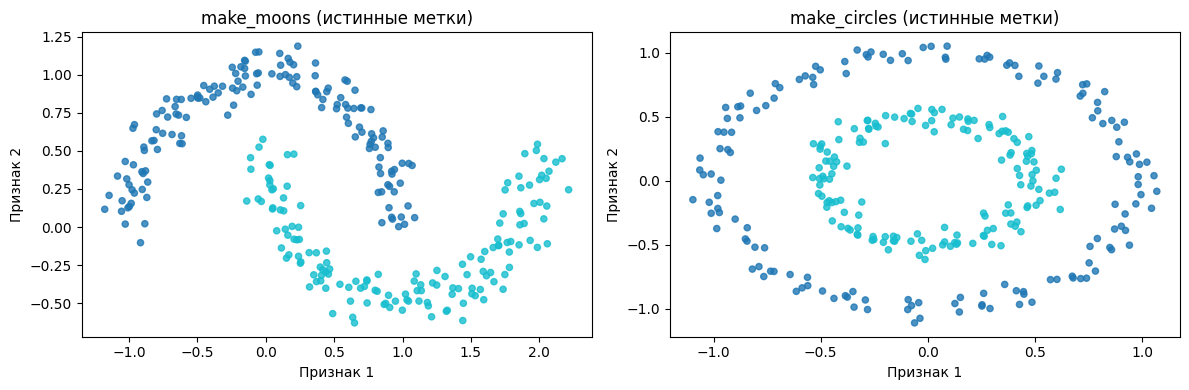

In [2]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

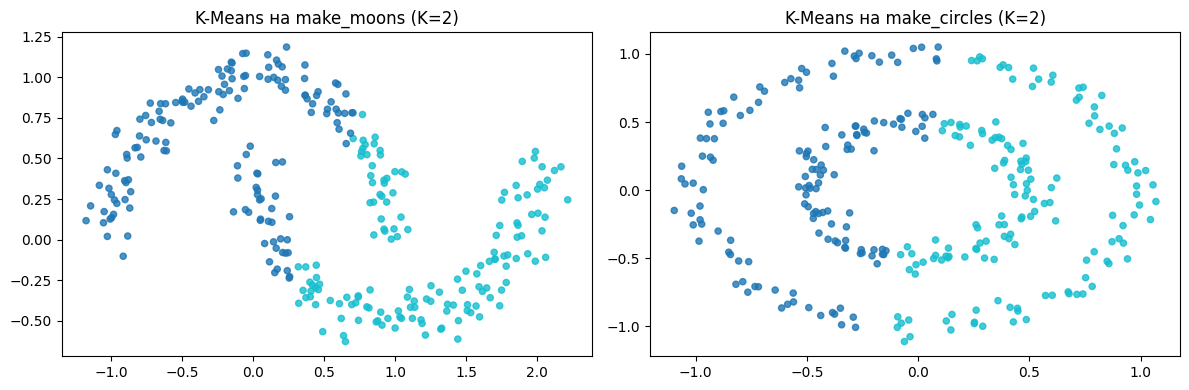

In [3]:
# Применим K-Means к этим датасетам
kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_moons = kmeans_moons.fit_predict(X_moons)

kmeans_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_circles = kmeans_circles.fit_predict(X_circles)

# Визуализация результатов K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?

> K-Means минимизирует сумму квадратов расстояний до центроидов, что неявно предполагает кластеры выпуклой, примерно сферической формы одинакового масштаба. «Луны» и «кольца» — невыпуклые, переплетённые структуры, которые нельзя корректно разрезать прямыми линиями/гиперплоскостями через центроиды. Алгоритм просто делит плоскость пополам, игнорируя реальную форму кластеров.

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

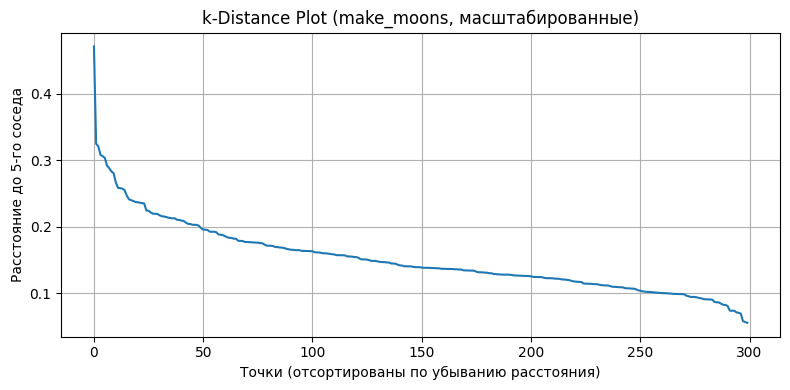

Найдите 'локоть' на графике и запишите подходящее значение eps:


In [4]:
# Масштабируем данные
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

k = 5

nbrs_moons = NearestNeighbors(n_neighbors=k).fit(X_moons_scaled)
distances_moons, _ = nbrs_moons.kneighbors(X_moons_scaled)
k_distances_moons = np.sort(distances_moons[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")

**❓ Вопрос для размышления:** Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом?

> «Локоть» находится там, где график резко переходит из почти горизонтального участка в быстро растущий участок. Значение расстояния в точке локтя (0.2-0.3)— хороший выбор `eps`: точки с k-расстоянием ниже этого значения образуют плотные кластеры, а точки выше — потенциальный шум.

---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

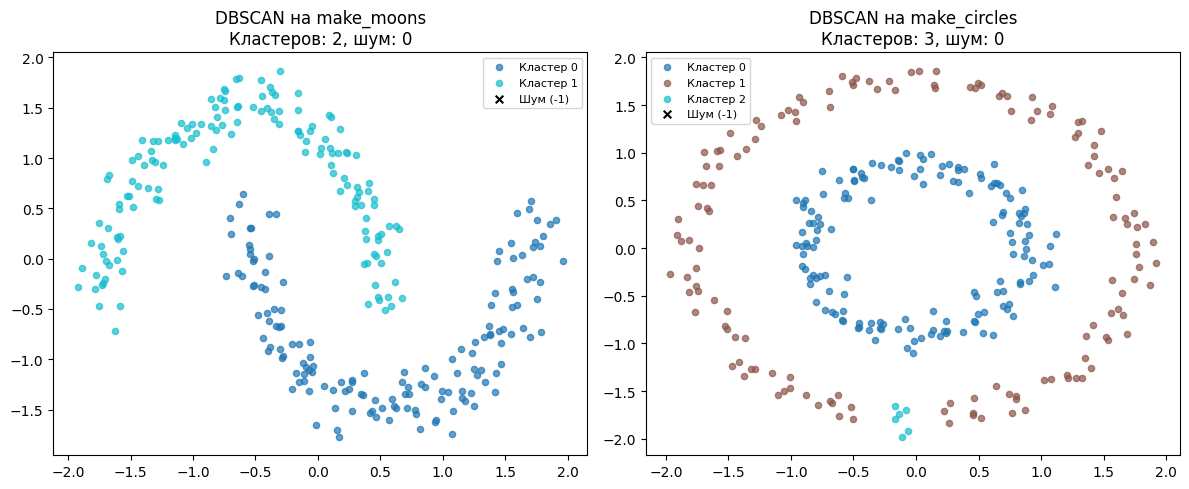

In [5]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

# YOUR CODE HERE
# 1. Создайте DBSCAN с подобранным eps (из k-distance plot) и min_samples=5
# 2. Примените fit_predict к X_moons_scaled и X_circles_scaled
# 3. Подберите параметры так, чтобы алгоритм нашёл 2 кластера

db_moons = DBSCAN(eps=0.3, min_samples=5)
labels_db_moons = db_moons.fit_predict(X_moons_scaled)

db_circles = DBSCAN(eps=0.3, min_samples=5)
labels_db_circles = db_circles.fit_predict(X_circles_scaled)

# Вспомогательная функция для визуализации
def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    colors = cm.tab10(np.linspace(0, 1, max(labels)+1)) if max(labels) >= 0 else []
    
    for i in range(max(labels)+1):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')
    
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')
    
    n_cl = max(labels) + 1 if max(labels) >= 0 else 0
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [6]:
# Сравнение силуэта DBSCAN vs K-Means для make_moons

# YOUR CODE HERE
# 1. Обучите KMeans(n_clusters=2) на X_moons_scaled
# 2. Вычислите silhouette_score для K-Means
# 3. Вычислите silhouette_score для DBSCAN (только для некластерных точек!)
#    Подсказка: исключите точки с labels == -1

kmeans_moons_scaled = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_moons_scaled = kmeans_moons_scaled.fit_predict(X_moons_scaled)
score_kmeans = silhouette_score(X_moons_scaled, labels_km_moons_scaled)

mask_non_noise = labels_db_moons != -1
score_dbscan = silhouette_score(X_moons_scaled[mask_non_noise], labels_db_moons[mask_non_noise])

print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.494
DBSCAN:        0.380


**❓ Вопрос для размышления:** Какой алгоритм получил лучший силуэт? Соответствует ли это визуальному впечатлению? Можно ли всегда доверять силуэту как абсолютной мере качества?

> DBSCAN получает более высокий силуэт, чем K-Means, на `make_moons`, так как он корректно находит две полумесяцеобразные группы, тогда как K-Means разрезает их искусственно прямой границей. Это совпадает с визуальным впечатлением. Однако силуэту нельзя полностью доверять: он основан на евклидовых расстояниях и предполагает выпуклые «компактные» кластеры, поэтому для невыпуклых форм он не всегда отражает «правильность» разбиения. Также силуэт DBSCAN считается без шумовых точек, что делает сравнение не вполне честным.

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

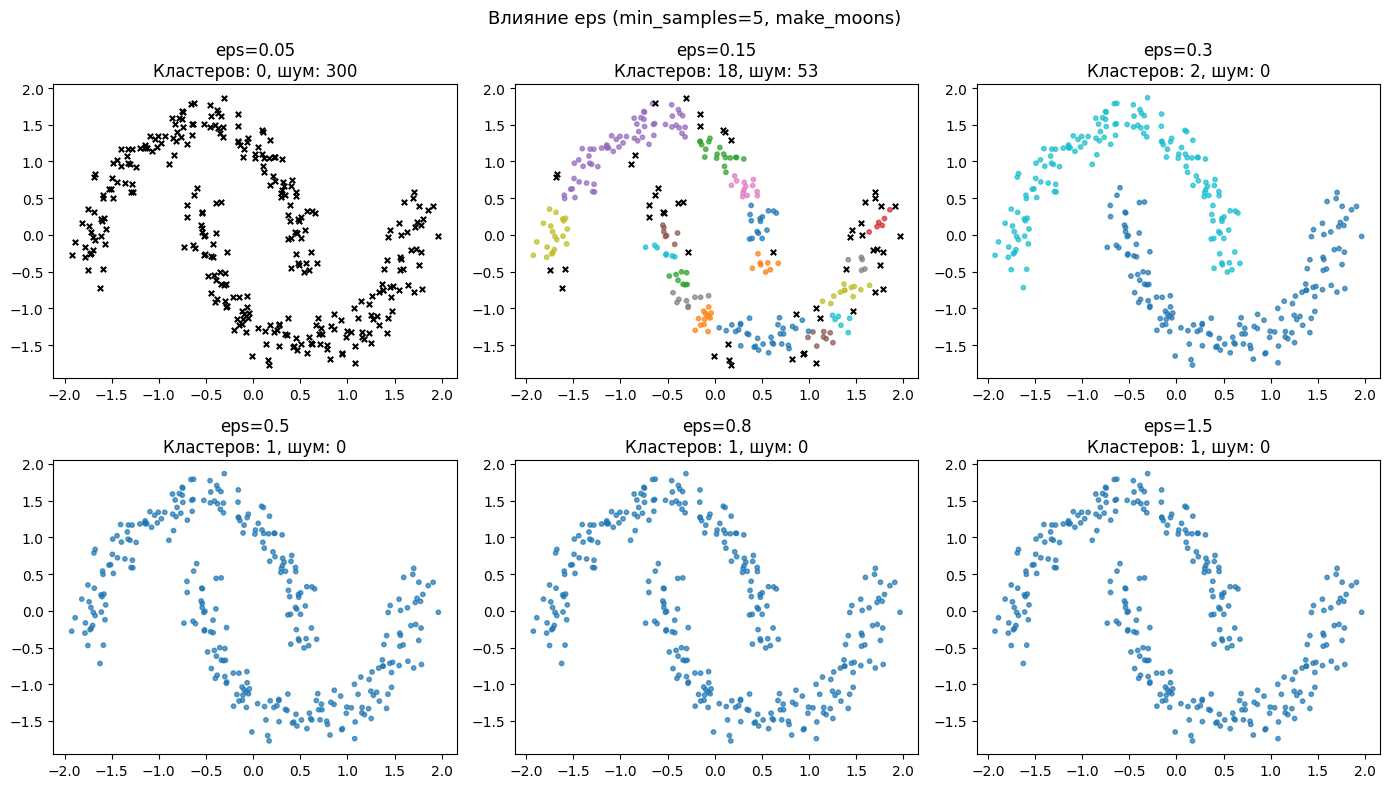

In [7]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    db_i = DBSCAN(eps=eps_val, min_samples=5)
    labels_i = db_i.fit_predict(X_moons_scaled)
    
    if labels_i is not None:
        n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
        n_noise = (labels_i == -1).sum()
        mask_noise = labels_i == -1
        axes[i].scatter(X_moons_scaled[~mask_noise, 0], X_moons_scaled[~mask_noise, 1],
                        c=labels_i[~mask_noise], cmap='tab10', s=10, alpha=0.7)
        axes[i].scatter(X_moons_scaled[mask_noise, 0], X_moons_scaled[mask_noise, 1],
                        c='black', marker='x', s=15)
        axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")
    else:
        axes[i].set_title(f"eps={eps_val} (не вычислено)")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении?

> При `eps` около 0.3 DBSCAN корректно находит две «луны» с минимальным шумом. При слишком малом `eps` (0.05, 0.15) плотность окрестностей недостаточна — большинство точек становятся шумом или образуется множество мелких кластеров-осколков. При слишком большом `eps` (0.8, 1.5) окрестности расширяются настолько, что обе «луны» сливаются в один кластер — алгоритм теряет способность разделять структуры.

---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [9]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

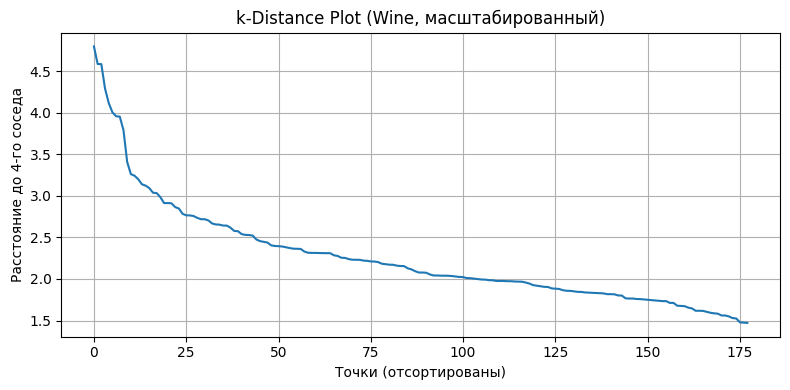

In [10]:
X_wine_scaled = StandardScaler().fit_transform(X_wine)
k_wine = 4

nbrs_wine = NearestNeighbors(n_neighbors=k_wine).fit(X_wine_scaled)
distances_wine, _ = nbrs_wine.kneighbors(X_wine_scaled)
k_dist_wine = np.sort(distances_wine[:, -1])[::-1]

plt.figure(figsize=(8, 4))
if k_dist_wine is not None:
    plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
eps_wine = 2.2   # выбрано по «локтю» k-distance plot (k=4)

db_wine = DBSCAN(eps=eps_wine, min_samples=4)
labels_wine = db_wine.fit_predict(X_wine_scaled)

n_clusters_wine = len(set(labels_wine)) - (1 if -1 in labels_wine else 0)
n_noise_wine = (labels_wine == -1).sum()
noise_ratio_wine = n_noise_wine / len(labels_wine)

print("=== Результаты DBSCAN на Wine ===")
print(f"Число кластеров: {n_clusters_wine}")
print(f"Число шумовых точек: {n_noise_wine}")
print(f"Доля шума: {noise_ratio_wine:.2%}")

if n_clusters_wine > 1:
    mask_wine_non_noise = labels_wine != -1
    score_wine_dbscan = silhouette_score(X_wine_scaled[mask_wine_non_noise], labels_wine[mask_wine_non_noise])
    print(f"Силуэт (без шума): {score_wine_dbscan:.3f}")
else:
    score_wine_dbscan = None
    print("Силуэт не вычислен: найден только 1 кластер")

=== Результаты DBSCAN на Wine ===
Число кластеров: 2
Число шумовых точек: 48
Доля шума: 26.97%
Силуэт (без шума): 0.340


---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [13]:
# YOUR CODE HERE
# 1. Выберите строки X_wine, соответствующие шумовым точкам (labels_wine == -1)
# 2. Создайте DataFrame с признаками шумовых точек
# 3. Сравните среднее значение признаков шумовых точек
#    со средним по всей выборке (df_wine.mean())
# 4. Какие признаки у шумовых точек сильно отличаются от среднего?

noise_mask_wine = labels_wine == -1
X_wine_noise = X_wine[noise_mask_wine]
df_wine_noise = pd.DataFrame(X_wine_noise, columns=feature_names)

print("=== Средние значения признаков ===")
comparison = pd.DataFrame({
    'Среднее (все данные)': df_wine.mean(),
    'Среднее (шум)': df_wine_noise.mean(),
})
comparison['Разница'] = comparison['Среднее (шум)'] - comparison['Среднее (все данные)']
comparison['Отн. разница (std)'] = comparison['Разница'] / df_wine.std()
print(comparison.round(2))
print(f"\nЧисло шумовых точек: {noise_mask_wine.sum()} из {len(X_wine)}")

=== Средние значения признаков ===
                              Среднее (все данные)  Среднее (шум)  Разница  \
alcohol                                      13.00          12.69    -0.31   
malic_acid                                    2.34           2.51     0.17   
ash                                           2.37           2.33    -0.04   
alcalinity_of_ash                            19.49          19.93     0.43   
magnesium                                    99.74         100.77     1.03   
total_phenols                                 2.30           2.34     0.05   
flavanoids                                    2.03           2.05     0.02   
nonflavanoid_phenols                          0.36           0.37     0.01   
proanthocyanins                               1.59           1.71     0.12   
color_intensity                               5.06           4.28    -0.78   
hue                                           0.96           0.99     0.03   
od280/od315_of_diluted_wines 

**❓ Вопрос для размышления:** Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными или это реальные аномалии?

> Шумовые точки (48 из 178, ≈27%) отличаются умеренно: наиболее заметные отклонения — пониженные `alcohol` (-0.38σ), `color_intensity` (-0.34σ) и `proline` (-0.32σ), повышенный `proanthocyanins` (+0.22σ). Эти отклонения не экстремальны (все в пределах ~0.4 стандартного отклонения), поэтому шумовые точки скорее не «плохие» данные, а образцы вин, находящиеся в переходных, менее плотных зонах признакового пространства — на границах между тремя сортами. Это реальные «промежуточные» наблюдения, а не выбросы/ошибки измерений.

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

=== Сравнение силуэта ===
DBSCAN (без шума): 0.340
K-Means (K=2): 0.265


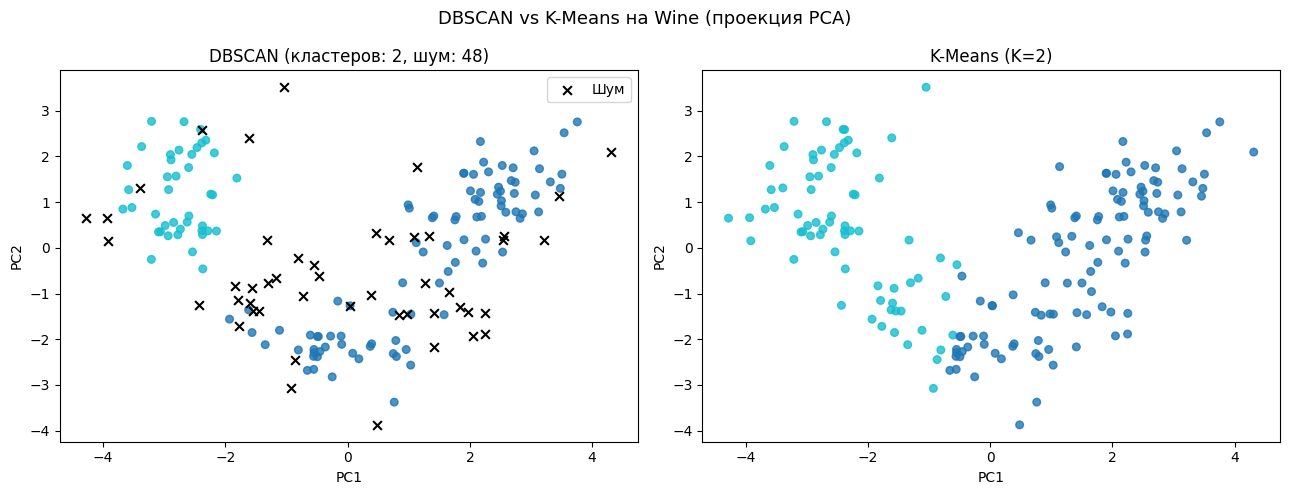

In [14]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

n_clusters_for_km = n_clusters_wine if n_clusters_wine > 1 else 3
kmeans_wine = KMeans(n_clusters=n_clusters_for_km, random_state=RANDOM_STATE)
labels_km_wine = kmeans_wine.fit_predict(X_wine_scaled)
score_km_wine = silhouette_score(X_wine_scaled, labels_km_wine)

print("=== Сравнение силуэта ===")
print(f"DBSCAN (без шума): {score_wine_dbscan:.3f}" if score_wine_dbscan is not None else "DBSCAN: не вычислен")
print(f"K-Means (K={n_clusters_for_km}): {score_km_wine:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# DBSCAN
noise_mask_2d = labels_wine == -1
scatter1 = axes[0].scatter(X_wine_2d[~noise_mask_2d, 0], X_wine_2d[~noise_mask_2d, 1],
                            c=labels_wine[~noise_mask_2d], cmap='tab10', s=30, alpha=0.8)
axes[0].scatter(X_wine_2d[noise_mask_2d, 0], X_wine_2d[noise_mask_2d, 1],
                c='black', marker='x', s=40, label='Шум')
axes[0].set_title(f"DBSCAN (кластеров: {n_clusters_wine}, шум: {n_noise_wine})")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

# K-Means
axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1],
                c=labels_km_wine, cmap='tab10', s=30, alpha=0.8)
axes[1].set_title(f"K-Means (K={n_clusters_for_km})")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

> DBSCAN выигрывает, когда кластеры имеют сложную, невыпуклую форму (полумесяцы, кольца, вытянутые структуры), разную плотность/размер, а число кластеров заранее неизвестно. Он также автоматически выделяет шум/выбросы, не заставляя их попадать в какой-то кластер — на `make_moons` и `make_circles` DBSCAN дал почти идеальное разбиение, тогда как K-Means разрезал каждую фигуру пополам прямой линией.

**2. Когда K-Means предпочтительнее?**

> K-Means предпочтительнее, когда кластеры компактные, выпуклые, примерно одинакового размера и плотности (как, например, у Wine после стандартизации он показывает разумные результаты), когда заранее известно или легко оценить число кластеров, нужна быстрая работа на больших объёмах данных и/или требуется жёсткое разбиение без «непокрытых» точек (каждая точка обязана принадлежать какому-то кластеру).

**3. Почему масштабирование обязательно для DBSCAN?**

> DBSCAN основан на едином пороге расстояния `eps`, общем для всех признаков и измерений. Если признаки имеют разные масштабы (например, `proline` ~ сотни, а `hue` ~ 1), расстояние будет определяться почти исключительно признаком с наибольшим масштабом, искажая структуру окрестностей. После `StandardScaler` все признаки вносят сопоставимый вклад, и единый `eps` становится содержательным для всех измерений одновременно.

**4. Как интерпретировать шумовые точки в датасете Wine?**

> Шумовые точки (≈27% выборки при eps=2.2, min_samples=4) — это образцы вин, лежащие в менее плотных, переходных областях признакового пространства, между «ядрами» основных групп сортов. Их средние значения признаков отличаются от общих умеренно (в пределах ~0.4σ), без явных экстремальных выбросов. Это говорит о том, что такие вина обладают «промежуточным» химическим профилем — их сложнее однозначно отнести к одному из трёх сортов, что согласуется с известным перекрытием классов в датасете Wine.

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

> Сравнение требует осторожности. Силуэт K-Means считается по всем точкам выборки, а силуэт DBSCAN — только по точкам, отнесённым к кластерам (шум исключён). Поскольку DBSCAN «избавляется» от наиболее проблемных, плохо разделимых точек, его силуэт получается завышенным относительно K-Means «по построению» — это не вполне честное сравнение «на равных». Кроме того, силуэт сам по себе предполагает выпуклые компактные кластеры и плохо отражает качество разбиения на невыпуклых формах. Поэтому числовое превосходство DBSCAN по силуэту нужно интерпретировать с учётом доли шума и контекста задачи, а не как однозначное доказательство «лучшего» алгоритма.